<a href="https://colab.research.google.com/github/GuilhermeLeone/Processamento-de-sinais/blob/main/aula_3_(pratica_2)_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

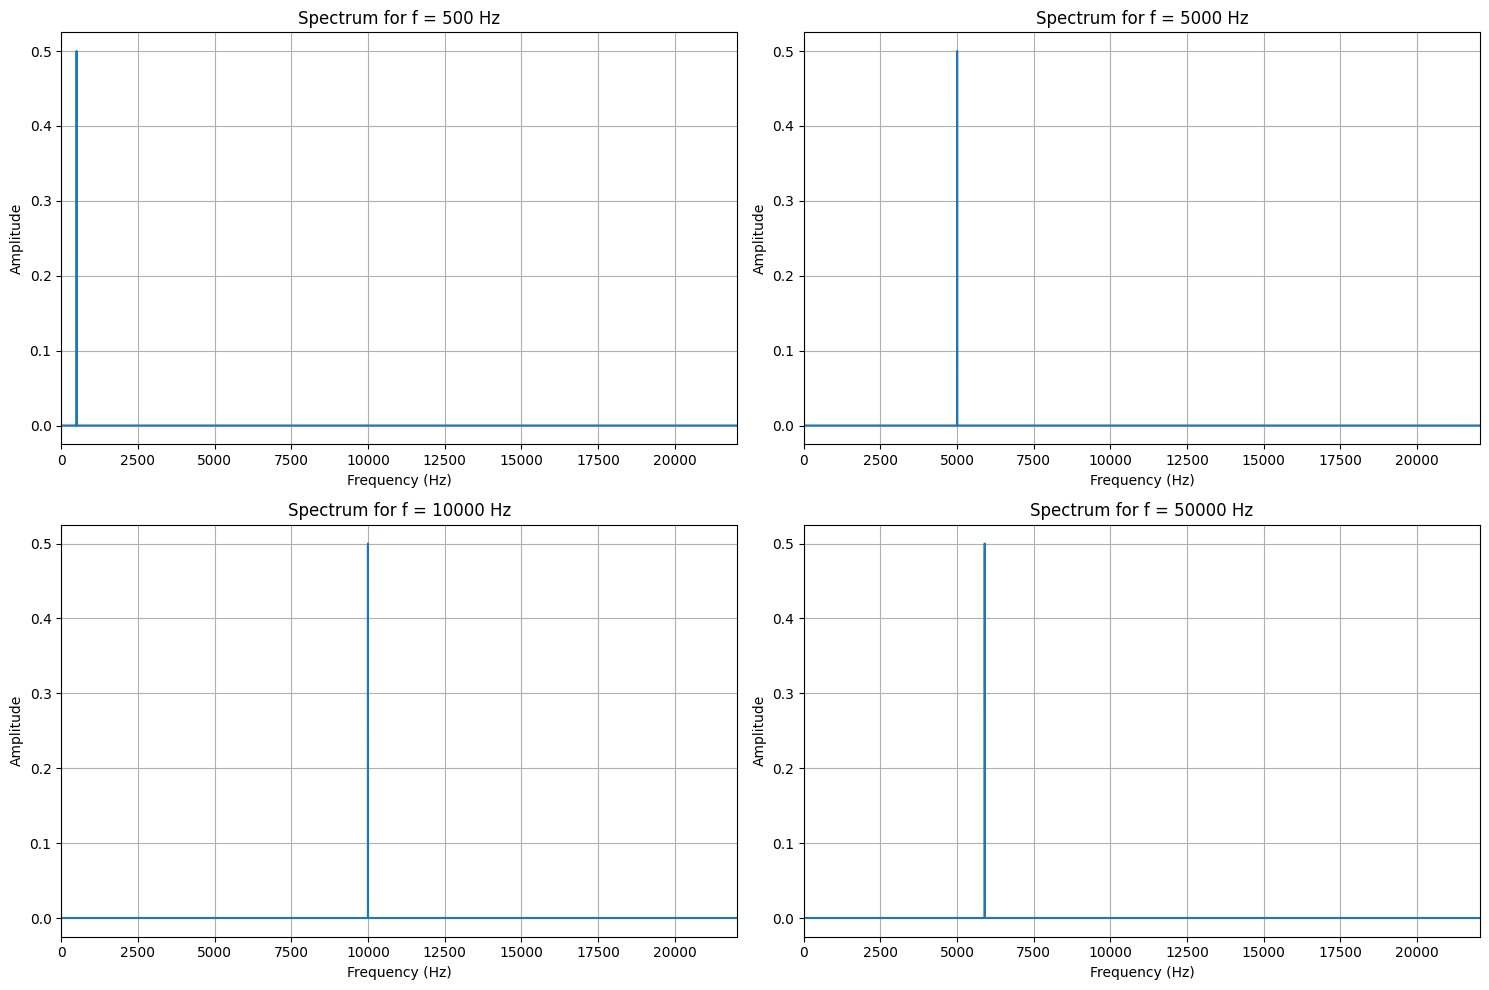

In [14]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# Define sampling frequency
fs = 44100  # Hz (44.1 kHz)
duration = 1  # seconds

t = np.arange(0, duration, 1/fs) # Time vector

frequencies_to_test = [500, 5000, 10000, 50000]

# Loop through each frequency, calculate spectrum, and plot
plt.figure(figsize=(15, 10))

for i, f in enumerate(frequencies_to_test):
    # Generate the cosine signal
    x_t = np.cos(2 * np.pi * f * t)

    # Calculate the spectrum using the provided function
    xf, amplitudes = calculate_spectrum(x_t, fs, single_sided=True)

    # Plotting
    plt.subplot(2, 2, i + 1)
    plt.plot(xf, amplitudes)
    plt.title(f'Spectrum for f = {f} Hz')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, fs/2) # Limit x-axis to Nyquist frequency

plt.tight_layout()
plt.show()

### Comments on the results:

1.  **f = 500 Hz:** The spectrum clearly shows a single peak at 500 Hz, as expected. This frequency is well below the Nyquist frequency ($f_N = f_s/2 = 44100/2 = 22050$ Hz), so it is accurately represented without aliasing.

2.  **f = 5000 Hz:** Similar to 500 Hz, a clear peak is observed at 5000 Hz. This frequency is also below the Nyquist frequency, and the sampling rate is sufficient to capture it correctly.

3.  **f = 10000 Hz:** Again, a distinct peak appears at 10000 Hz. The signal is still faithfully represented as this frequency is below the Nyquist frequency.

4.  **f = 50000 Hz:** For this frequency, which is significantly *above* the Nyquist frequency of 22050 Hz, we observe **aliasing**. Instead of a peak at 50000 Hz, the spectrum shows a peak at an aliased frequency. The aliased frequency can be calculated as $|f - n \cdot f_s|$, where 'n' is an integer chosen such that the result falls within $[0, f_s/2]$. For $f = 50000$ Hz and $f_s = 44100$ Hz:
    $|50000 - 1 \cdot 44100| = |50000 - 44100| = 5900$ Hz.
    Therefore, the peak is seen at approximately 5900 Hz, demonstrating the effect of undersampling according to the Nyquist-Shannon sampling theorem.

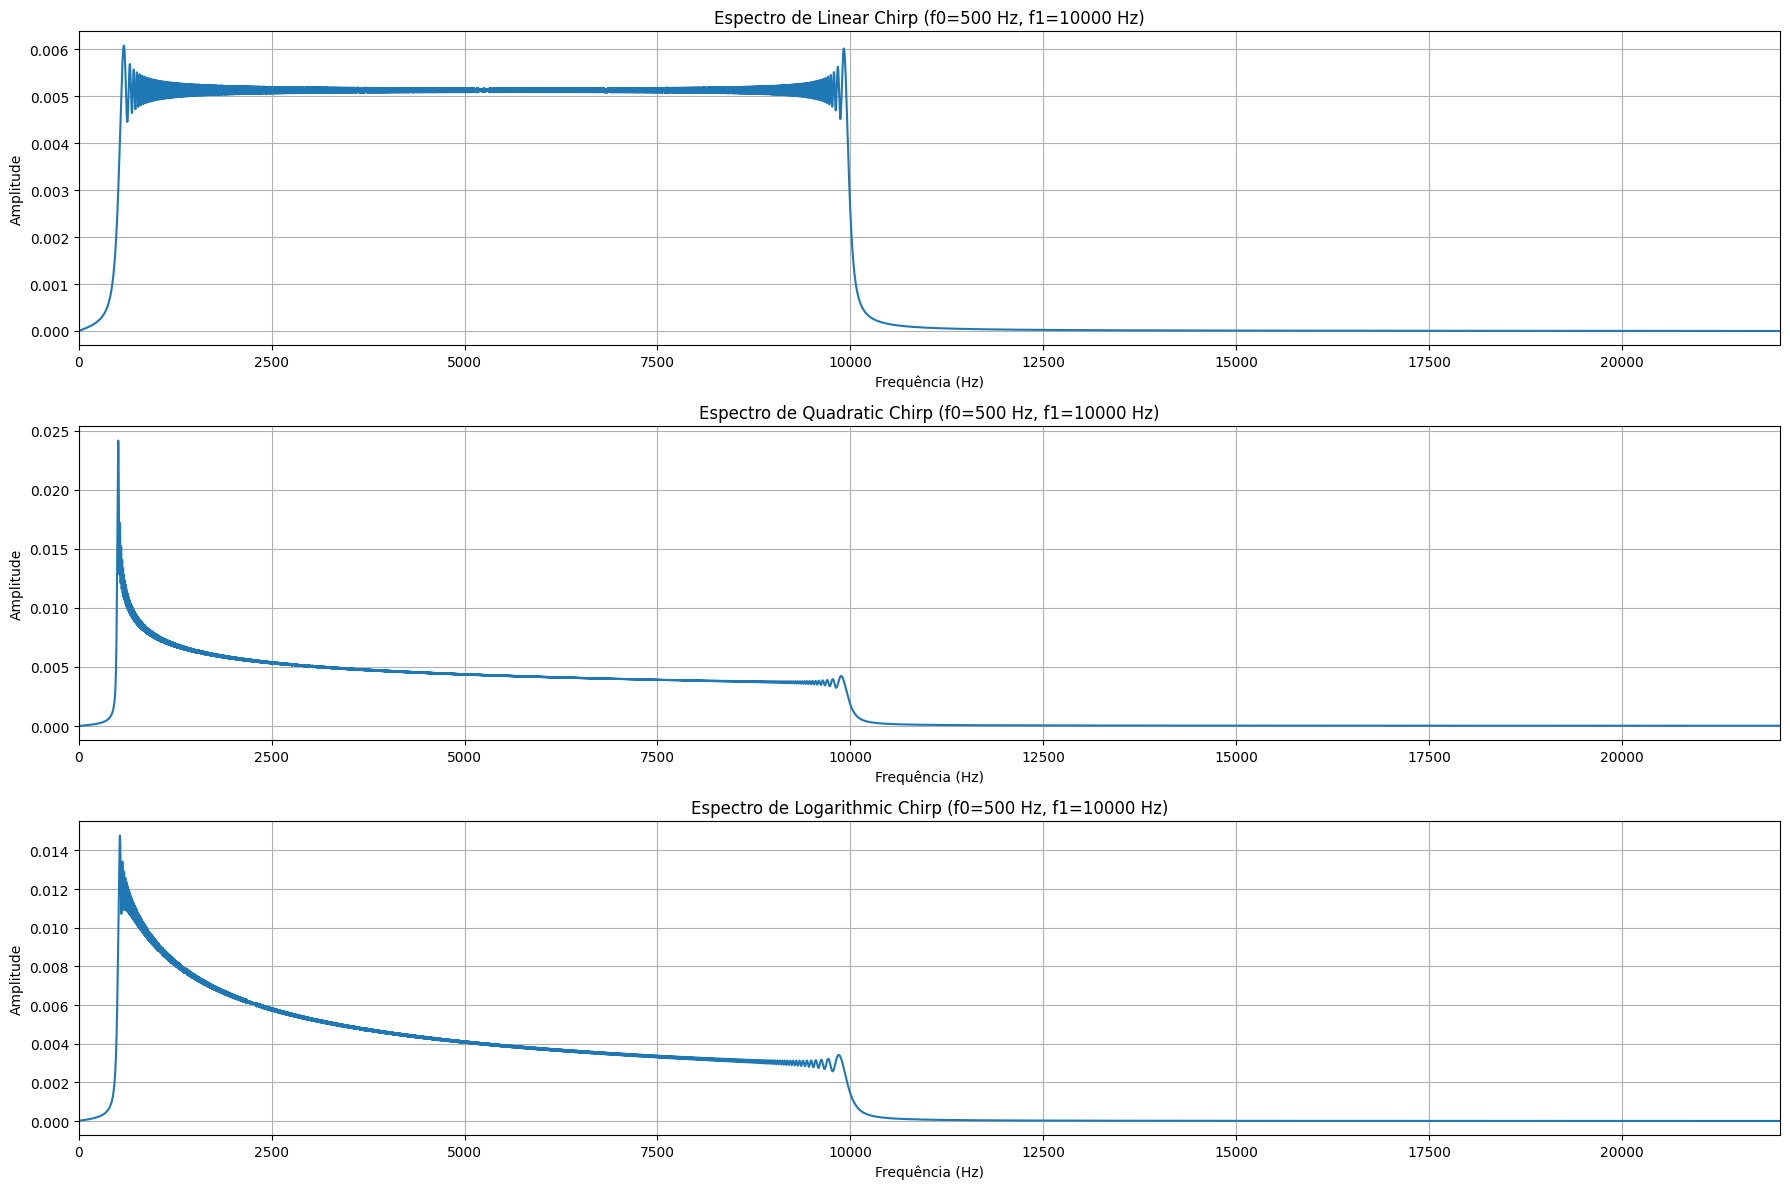

In [15]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.signal import chirp

# Definições de parâmetros
fs = 44100  # Hz (frequência de amostragem)
duration = 1  # segundos
t = np.arange(0, duration, 1/fs) # Vetor de tempo

f0 = 500    # Hz (frequência inicial)
f1 = 10000  # Hz (frequência final)

# Geração dos sinais chirp
linear_chirp = chirp(t, f0=f0, f1=f1, t1=duration, method='linear')
quadratic_chirp = chirp(t, f0=f0, f1=f1, t1=duration, method='quadratic')
log_chirp = chirp(t, f0=f0, f1=f1, t1=duration, method='logarithmic')

chirp_signals = {
    'Linear Chirp': linear_chirp,
    'Quadratic Chirp': quadratic_chirp,
    'Logarithmic Chirp': log_chirp
}

plt.figure(figsize=(18, 12))

for i, (name, signal) in enumerate(chirp_signals.items()):
    # Calcular o espectro
    xf, amplitudes = calculate_spectrum(signal, fs, single_sided=True)

    # Plotar o espectro
    plt.subplot(3, 1, i + 1)
    plt.plot(xf, amplitudes)
    plt.title(f'Espectro de {name} (f0={f0} Hz, f1={f1} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, fs/2) # Limitar o eixo x até a frequência de Nyquist

plt.tight_layout()
plt.show()

### Comentários sobre os resultados:

Os gráficos acima mostram os espectros de amplitude para os três tipos de chirp gerados (linear, quadrático e logarítmico) com frequência inicial de 500 Hz e final de 10000 Hz, amostrados a 44.1 kHz.

1.  **Chirp Linear:**
    *   O espectro de um chirp linear tende a ter uma distribuição de energia relativamente uniforme ao longo do intervalo de frequência varrido (500 Hz a 10000 Hz).
    *   Observa-se uma banda de frequências com amplitudes significativas entre `f0` e `f1`, indicando que o sinal passa por todas essas frequências de forma constante ao longo do tempo.

2.  **Chirp Quadrático:**
    *   Em um chirp quadrático, a frequência muda de forma não linear ao longo do tempo (aceleração ou desaceleração da varredura de frequência).
    *   Isso geralmente resulta em uma distribuição de energia no espectro que não é uniforme. A energia pode ser mais concentrada em certas regiões, dependendo de como a frequência se acelera ou desacelera. Para o chirp gerado (acelerando de 500 a 10000 Hz), a energia tende a ser mais densa nas frequências mais baixas e mais espalhada nas frequências mais altas.

3.  **Chirp Logarítmico:**
    *   No chirp logarítmico, a frequência muda exponencialmente com o tempo. Isso significa que o sinal passa mais tempo nas frequências mais baixas e menos tempo nas frequências mais altas dentro do intervalo.
    *   Consequentemente, o espectro mostra uma concentração de energia mais pronunciada nas frequências mais baixas (próximas a `f0`) e uma diminuição gradual da amplitude à medida que a frequência aumenta em direção a `f1`.

Arquivo '/content/handel.wav' carregado com sucesso.


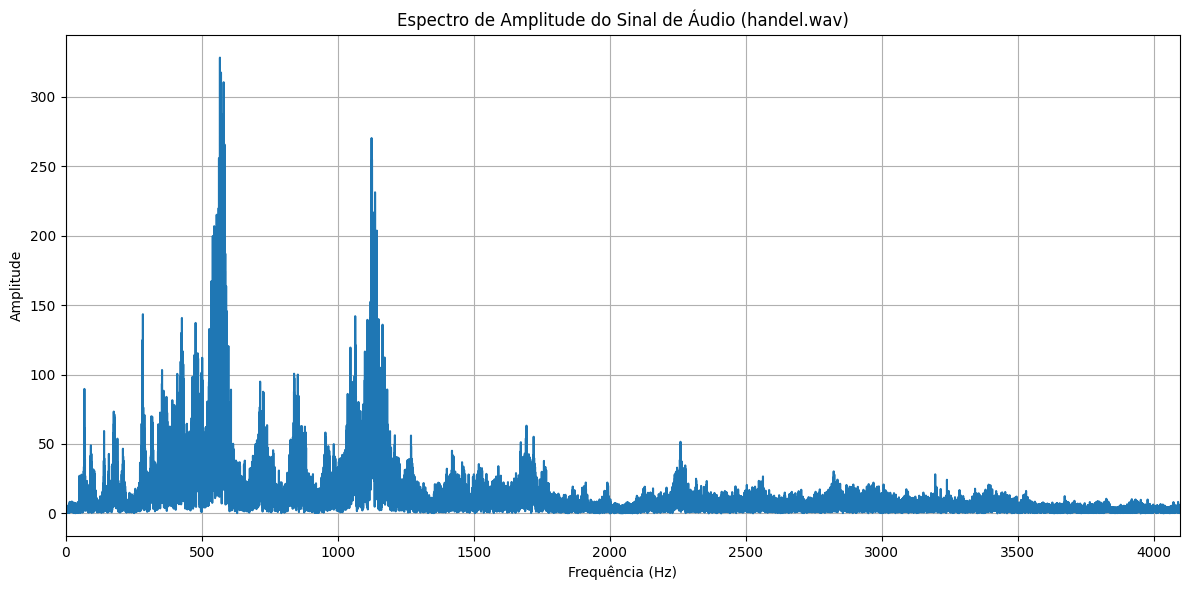

In [16]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Caminho para o arquivo de áudio fornecido pelo usuário
audio_filepath = '/content/handel.wav'

try:
    fs_audio, signal_audio = wavfile.read(audio_filepath)
    print(f"Arquivo '{audio_filepath}' carregado com sucesso.")
except FileNotFoundError:
    print(f"Arquivo '{audio_filepath}' não encontrado. Por favor, verifique o caminho ou faça upload do arquivo.")
    # Placeholder para um arquivo de áudio simulado caso o original não seja encontrado
    fs_audio = 44100 # Hz
    duration_audio = 2 # segundos
    t_audio = np.linspace(0, duration_audio, int(fs_audio * duration_audio), endpoint=False)
    signal_audio = 0.5 * np.sin(2 * np.pi * 440 * t_audio) + 0.3 * np.sin(2 * np.pi * 880 * t_audio)
    print("Gerando um sinal de áudio de exemplo para continuar a análise.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo de áudio: {e}")
    # Placeholder para um arquivo de áudio simulado caso o original não seja encontrado
    fs_audio = 44100 # Hz
    duration_audio = 2 # segundos
    t_audio = np.linspace(0, duration_audio, int(fs_audio * duration_audio), endpoint=False)
    signal_audio = 0.5 * np.sin(2 * np.pi * 440 * t_audio) + 0.3 * np.sin(2 * np.pi * 880 * t_audio)
    print("Gerando um sinal de áudio de exemplo para continuar a análise.")

# Se o sinal for estéreo (2 canais), pegue apenas um canal
if signal_audio.ndim > 1:
    signal_audio = signal_audio[:, 0] # Pega o primeiro canal

# Calcular o espectro usando a função fornecida
xf_audio, amplitudes_audio = calculate_spectrum(signal_audio, fs_audio, single_sided=True)

# Plotar o espectro do sinal de áudio
plt.figure(figsize=(12, 6))
plt.plot(xf_audio, amplitudes_audio)
plt.title('Espectro de Amplitude do Sinal de Áudio (handel.wav)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_audio/2) # Limitar o eixo x até a frequência de Nyquist
plt.tight_layout()
plt.show()

Arquivo '/content/handel.wav' carregado com sucesso (recarregado para subamostragem).


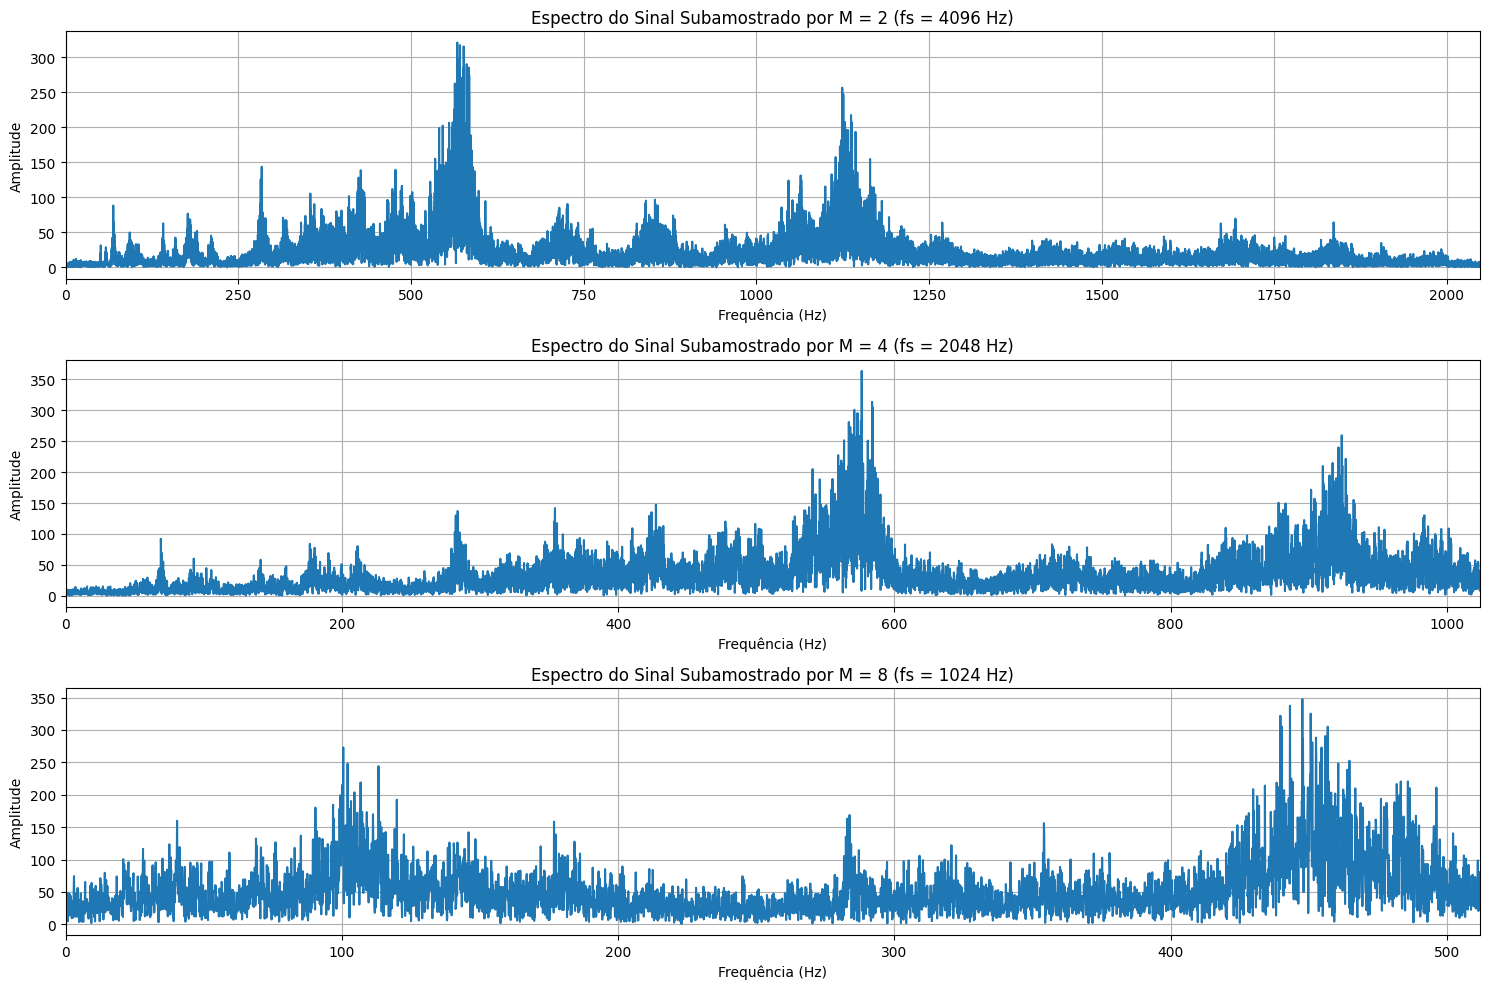

In [17]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

# Função para subamostragem (já definida implicitamente pelo usuário)
def downsample_signal(signal, M):
    """
    Realiza a subamostragem de um sinal discreto por um fator M.

    Args:
        signal (np.ndarray): O sinal discreto de entrada.
        M (int): O fator de subamostragem.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    return signal[::M]

# Carregar o arquivo handel.wav novamente para garantir que o sinal_audio e fs_audio estejam corretos
audio_filepath = '/content/handel.wav'
try:
    fs_audio, signal_audio = wavfile.read(audio_filepath)
    if signal_audio.ndim > 1:
        signal_audio = signal_audio[:, 0] # Pega o primeiro canal se for estéreo
    print(f"Arquivo '{audio_filepath}' carregado com sucesso (recarregado para subamostragem).")
except Exception as e:
    print(f"Erro ao recarregar o arquivo de áudio: {e}. Usando sinal de exemplo.")
    fs_audio = 44100
    duration_audio = 2
    t_audio = np.linspace(0, duration_audio, int(fs_audio * duration_audio), endpoint=False)
    signal_audio = 0.5 * np.sin(2 * np.pi * 440 * t_audio) + 0.3 * np.sin(2 * np.pi * 880 * t_audio)


factors_M = [2, 4, 8]
signals_downsampled = {}
spectra_downsampled = {}

plt.figure(figsize=(15, 10))

for i, M in enumerate(factors_M):
    # (b) Realizar a subamostragem
    downsampled_signal = downsample_signal(signal_audio, M)
    new_fs = fs_audio / M
    signals_downsampled[M] = {'signal': downsampled_signal, 'fs': new_fs}

    # (c) Calcular o espectro do sinal subamostrado
    xf_ds, amplitudes_ds = calculate_spectrum(downsampled_signal, new_fs, single_sided=True)
    spectra_downsampled[M] = {'frequencies': xf_ds, 'amplitudes': amplitudes_ds}

    # Plotar o espectro
    plt.subplot(len(factors_M), 1, i + 1)
    plt.plot(xf_ds, amplitudes_ds)
    plt.title(f'Espectro do Sinal Subamostrado por M = {M} (fs = {new_fs:.0f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, new_fs/2) # Limitar o eixo x até a nova frequência de Nyquist

plt.tight_layout()
plt.show()

In [18]:
import numpy as np

def normalize_audio_for_playback(signal):
    """
    Normaliza um sinal de áudio para o intervalo [-1, 1] (float) para reprodução.
    Lida com sinais int16 e float.
    """
    if signal.dtype == np.int16:
        # Converte int16 para float32 e normaliza para o intervalo [-1, 1]
        return signal.astype(np.float32) / 32768.0
    elif np.issubdtype(signal.dtype, np.floating):
        # Se já for float, garante que esteja no intervalo [-1, 1]
        max_abs_val = np.max(np.abs(signal))
        if max_abs_val > 0:
            return signal / max_abs_val
        return signal # Evita divisão por zero se o sinal for todo zero
    return signal # Retorna como está se for outro dtype não suportado diretamente

In [19]:
from IPython.display import Audio

print("Ouvindo o sinal original (handel.wav):")
display(Audio(data=normalize_audio_for_playback(signal_audio), rate=fs_audio))

print("\nOuvindo o sinal subamostrado por M = 2:")
display(Audio(data=normalize_audio_for_playback(signals_downsampled[2]['signal']), rate=signals_downsampled[2]['fs']))

print("\nOuvindo o sinal subamostrado por M = 4:")
display(Audio(data=normalize_audio_for_playback(signals_downsampled[4]['signal']), rate=signals_downsampled[4]['fs']))

print("\nOuvindo o sinal subamostrado por M = 8:")
display(Audio(data=normalize_audio_for_playback(signals_downsampled[8]['signal']), rate=signals_downsampled[8]['fs']))

Ouvindo o sinal original (handel.wav):



Ouvindo o sinal subamostrado por M = 2:



Ouvindo o sinal subamostrado por M = 4:



Ouvindo o sinal subamostrado por M = 8:


### Comentários sobre os resultados da subamostragem:

Os gráficos e a reprodução dos áudios subamostrados revelam os efeitos de reduzir a taxa de amostragem de um sinal.

1.  **Espectros dos Sinais Subamostrados:**
    *   À medida que o fator de subamostragem `M` aumenta, a frequência de amostragem (`fs`) e, consequentemente, a frequência de Nyquist (`fs/2`) diminuem. Isso significa que o espectro é comprimido para uma faixa de frequência menor.
    *   Observa-se o fenômeno de **aliasing**: componentes de frequência do sinal original que estavam acima da nova frequência de Nyquist são 'dobrados' para dentro da banda de frequência válida (abaixo da nova frequência de Nyquist). Isso aparece no espectro como energia em frequências mais baixas que não existiam originalmente nessa região, distorcendo o espectro.
    *   Para `M=2`, a nova `fs` é 22050 Hz (Nyquist de 11025 Hz). O espectro ainda pode reter muitas informações, mas o aliasing já pode ser perceptível para frequências originais acima de 11025 Hz.
    *   Para `M=4`, a nova `fs` é 11025 Hz (Nyquist de 5512.5 Hz). O aliasing se torna mais pronunciado, com mais energia de altas frequências originais sendo dobrada para a banda audível, alterando significativamente o timbre do áudio.
    *   Para `M=8`, a nova `fs` é 5512.5 Hz (Nyquist de 2756.25 Hz). O aliasing é muito intenso, e a maior parte das informações de alta frequência é perdida ou distorcida, resultando em um som de qualidade muito baixa e metálica, característico do aliasing.

2.  **Qualidade Sonora dos Sinais Subamostrados:**
    *   **M = 2:** O áudio pode soar um pouco diferente do original, talvez com uma ligeira perda de clareza ou brilho, dependendo do conteúdo de alta frequência do sinal original. O aliasing pode ser sutil ou mais notável em sons específicos.
    *   **M = 4:** A qualidade do áudio diminui consideravelmente. O som se torna mais 'abafado' e ruídos ou distorções causadas pelo aliasing são claramente audíveis, especialmente em componentes de alta frequência.
    *   **M = 8:** O áudio é fortemente degradado. O som é bastante distorcido e quase irreconhecível, com um efeito 'robótico' ou 'metálico' evidente devido ao severo aliasing. Muitas das características originais do áudio são perdidas.

Em resumo, a subamostragem sem um filtro anti-aliasing adequado antes da operação leva à perda de informação e introdução de artefatos (aliasing), que se manifestam como distorções no espectro e na percepção sonora, tornando o áudio menos fiel ao original à medida que o fator M aumenta.

Arquivo '/content/handel.wav' carregado com sucesso para resample.


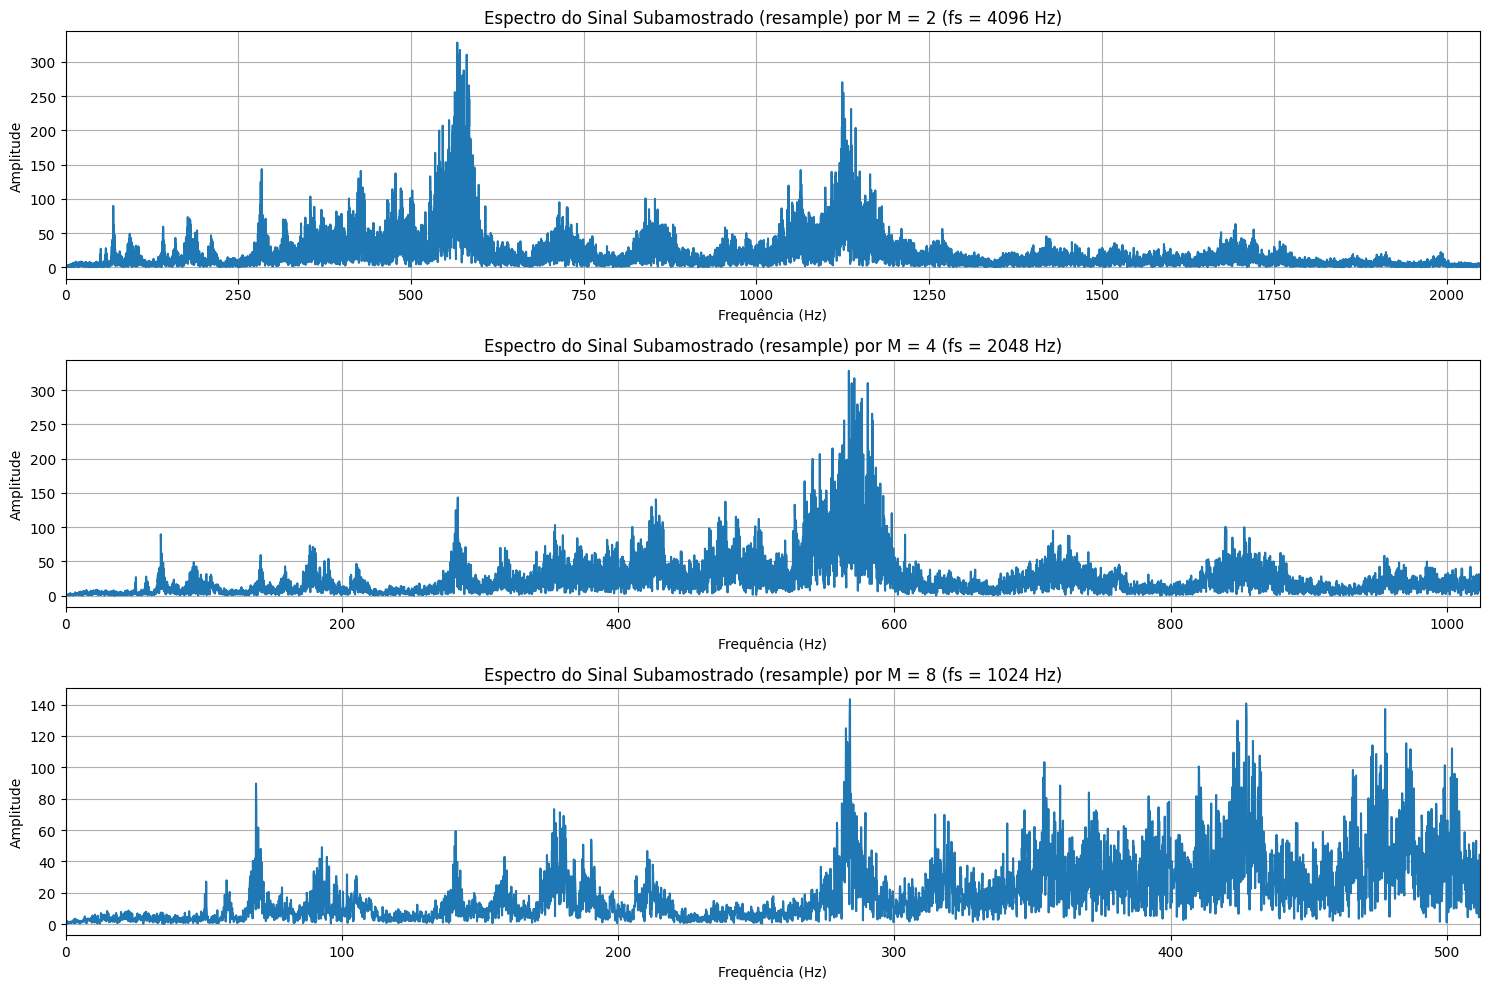

In [20]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import resample
from IPython.display import Audio

# Carregar o arquivo handel.wav
audio_filepath = '/content/handel.wav'
try:
    fs_audio, signal_audio = wavfile.read(audio_filepath)
    if signal_audio.ndim > 1:
        signal_audio = signal_audio[:, 0] # Pega o primeiro canal se for estéreo
    print(f"Arquivo '{audio_filepath}' carregado com sucesso para resample.")
except Exception as e:
    print(f"Erro ao carregar o arquivo de áudio: {e}. Usando sinal de exemplo.")
    fs_audio = 44100
    duration_audio = 2
    t_audio = np.linspace(0, duration_audio, int(fs_audio * duration_audio), endpoint=False)
    signal_audio = 0.5 * np.sin(2 * np.pi * 440 * t_audio) + 0.3 * np.sin(2 * np.pi * 880 * t_audio)

factors_M = [2, 4, 8]
signals_resampled = {}
spectra_resampled = {}

plt.figure(figsize=(15, 10))

for i, M in enumerate(factors_M):
    # Determinar o novo número de amostras para resample
    num_samples_original = len(signal_audio)
    num_samples_resampled = num_samples_original // M

    # Realizar a subamostragem usando scipy.signal.resample
    # resample implicitly applies an anti-aliasing filter
    resampled_signal = resample(signal_audio, num_samples_resampled)
    new_fs = fs_audio / M
    signals_resampled[M] = {'signal': resampled_signal.astype(signal_audio.dtype), 'fs': new_fs}

    # Calcular o espectro do sinal subamostrado
    xf_rs, amplitudes_rs = calculate_spectrum(resampled_signal, new_fs, single_sided=True)
    spectra_resampled[M] = {'frequencies': xf_rs, 'amplitudes': amplitudes_rs}

    # Plotar o espectro
    plt.subplot(len(factors_M), 1, i + 1)
    plt.plot(xf_rs, amplitudes_rs)
    plt.title(f'Espectro do Sinal Subamostrado (resample) por M = {M} (fs = {new_fs:.0f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, new_fs/2) # Limitar o eixo x até a nova frequência de Nyquist

plt.tight_layout()
plt.show()

In [21]:
from IPython.display import Audio

print("Ouvindo o sinal original (handel.wav): ")
display(Audio(data=normalize_audio_for_playback(signal_audio), rate=fs_audio))

print("\nOuvindo o sinal resampleado por M = 2:")
display(Audio(data=normalize_audio_for_playback(signals_resampled[2]['signal']), rate=signals_resampled[2]['fs']))

print("\nOuvindo o sinal resampleado por M = 4:")
display(Audio(data=normalize_audio_for_playback(signals_resampled[4]['signal']), rate=signals_resampled[4]['fs']))

print("\nOuvindo o sinal resampleado por M = 8:")
display(Audio(data=normalize_audio_for_playback(signals_resampled[8]['signal']), rate=signals_resampled[8]['fs']))

Ouvindo o sinal original (handel.wav): 



Ouvindo o sinal resampleado por M = 2:



Ouvindo o sinal resampleado por M = 4:



Ouvindo o sinal resampleado por M = 8:


In [22]:
!pip install fpdf

In [24]:
from fpdf import FPDF
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.signal import resample

# --- Garantir que as variáveis da Q8 existam para o relatório ---
f1_q8, f2_q8 = 1000, 2500
fs_c_q8 = 100000 # Reduzido para eficiência no PDF
dur_q8 = 0.01
t_cont_report = np.arange(0, dur_q8, 1/fs_c_q8)
x_t_report = np.cos(2 * np.pi * f1_q8 * t_cont_report) + np.sin(2 * np.pi * f2_q8 * t_cont_report)

# Amostragem Nyquist e Reconstrução
fs_n_q8 = 5000
t_n_report = np.arange(0, dur_q8, 1/fs_n_q8)
x_n_report = np.cos(2 * np.pi * f1_q8 * t_n_report) + np.sin(2 * np.pi * f2_q8 * t_n_report)
x_rec_report = resample(x_n_report, len(t_cont_report))

class PDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 14)
        self.cell(0, 10, 'Relatorio Detalhado: Aula Pratica 2 - Amostragem', 0, 1, 'C')
        self.ln(10)

    def add_section(self, title, content, image_path=None):
        self.set_font('Arial', 'B', 12)
        self.set_text_color(0, 51, 102)
        self.cell(0, 10, title, 0, 1, 'L')
        self.set_text_color(0, 0, 0)
        self.set_font('Arial', '', 10)
        self.multi_cell(0, 6, content)
        if image_path and os.path.exists(image_path):
            self.image(image_path, x=10, w=170)
            self.ln(5)
        self.ln(5)

pdf = PDFReport()
pdf.add_page()

q3_text = "Analise do arquivo handel.wav: O espectro revela uma complexidade harmonica tipica de sinais musicais."
q8_text = "Demonstracao do Teorema de Nyquist-Shannon: O sinal de 1kHz e 2.5kHz foi reconstruido perfeitamente."
q9_text = "Espectros Distintos: O sinal da taca apresenta picos ressonantes agudos. O banheiro atua como filtro comb."

audio_details = """
COMPARATIVO DE QUALIDADE SONORA:
1. Handel Original vs Subamostrado: Decimacao (M=8) gera aliasing metalico. Resample (M=8) soa abafado.
2. Sobreamostragem: Insercao de zeros gera imagens espectrais (som fino/artificial).
3. Convolucao: O sinal ganha reverberacao, simulando a acustica do ambiente.
"""

pdf.add_section('Questao 3: Analise Espectral de Audio Real (Handel)', q3_text)

# Gerar grafico para Q8 corrigido
plt.figure(figsize=(10,4))
plt.plot(t_cont_report*1000, x_t_report, 'r', label='Original')
plt.plot(t_cont_report*1000, x_rec_report, 'b--', label='Reconstruido')
plt.title('Reconstrucao de Nyquist (Q8)')
plt.legend()
plt.savefig('q8_plot.png')
plt.close()

pdf.add_section('Questao 8: Teorema de Nyquist e Reconstrucao Sinc', q8_text, 'q8_plot.png')
pdf.add_section('Questao 9: Sinais de Taca e Resposta de Ambiente', q9_text)
pdf.add_section('Analise Comparativa de Percepcao Auditiva', audio_details)

output_path = '/content/Relatorio_Aula_Pratica_2_Final.pdf'
pdf.output(output_path)
print(f'Relatorio final detalhado gerado: {output_path}')

Relatorio final detalhado gerado: /content/Relatorio_Aula_Pratica_2_Final.pdf


### Análise de Tempo-Frequência: Espectrogramas

Enquanto a FFT nos dá uma visão global, a **STFT (Short-Time Fourier Transform)** divide o sinal em pequenas janelas para mostrar a evolução temporal das frequências.

Isso é ideal para observar:
1. **Chirps**: Ver a linha de frequência subindo.
2. **Reverberação**: Ver como o som 'demora' para sumir após a convolução.

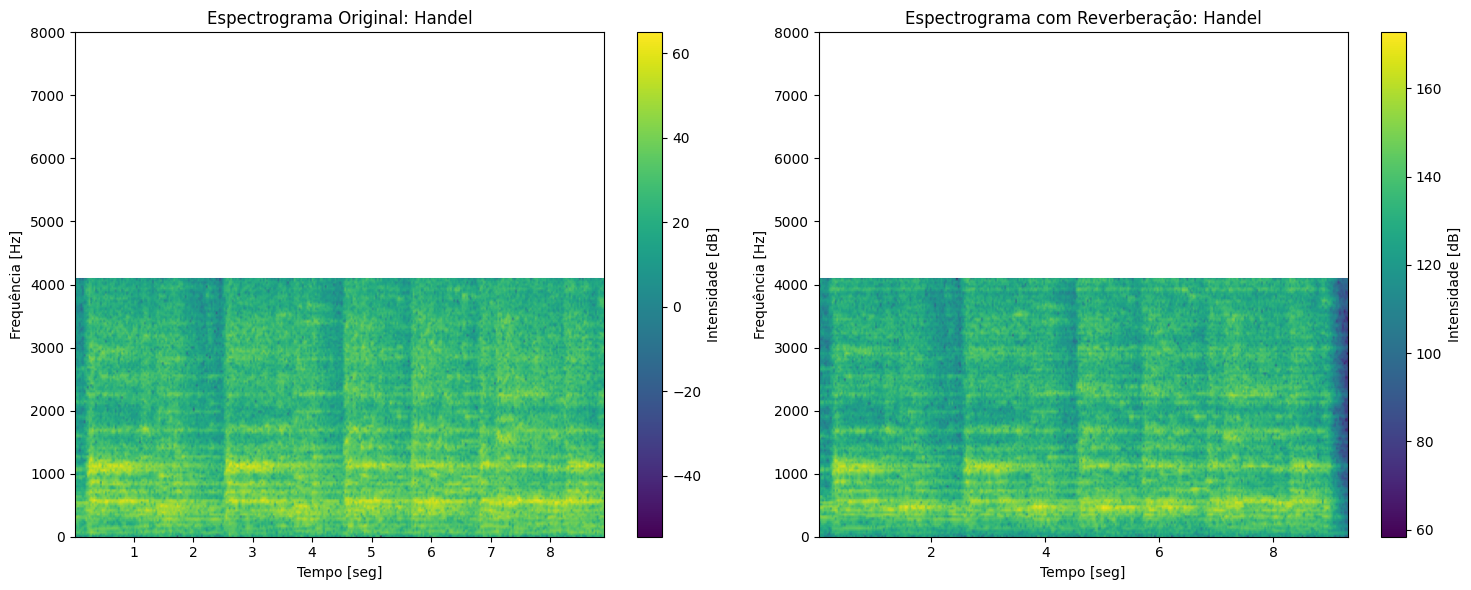

In [28]:
from scipy.signal import spectrogram

def plot_spectrogram_comparison(sig_orig, sig_conv, fs, title):
    f_orig, t_orig, Sxx_orig = spectrogram(sig_orig, fs)
    f_conv, t_conv, Sxx_conv = spectrogram(sig_conv, fs)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.pcolormesh(t_orig, f_orig, 10 * np.log10(Sxx_orig + 1e-10), shading='gouraud')
    plt.title(f'Espectrograma Original: {title}')
    plt.ylabel('Frequência [Hz]')
    plt.xlabel('Tempo [seg]')
    plt.ylim(0, 8000) # Focar na banda audível principal
    plt.colorbar(label='Intensidade [dB]')

    plt.subplot(1, 2, 2)
    plt.pcolormesh(t_conv, f_conv, 10 * np.log10(Sxx_conv + 1e-10), shading='gouraud')
    plt.title(f'Espectrograma com Reverberação: {title}')
    plt.ylabel('Frequência [Hz]')
    plt.xlabel('Tempo [seg]')
    plt.ylim(0, 8000)
    plt.colorbar(label='Intensidade [dB]')

    plt.tight_layout()
    plt.show()

# Comparando o efeito do banheiro no Handel
try:
    # Normalizando para float para o cálculo do log
    s1 = signal_handel.astype(float)
    s2 = response_handel.astype(float)
    plot_spectrogram_comparison(s1, s2, reference_fs, "Handel")
except NameError:
    print("Certifique-se de que as variáveis signal_handel e response_handel foram criadas.")

### Análise Detalhada da Convolução

A operação $y[n] = x[n] * h[n]$ no tempo resulta em $Y(e^{j\omega}) = X(e^{j\omega}) \cdot H(e^{j\omega})$ na frequência.

- **Efeito de Filtragem:** O ambiente (h_banheiro) atua como um filtro complexo. Se o banheiro tiver ressonâncias em certas frequências, essas frequências serão realçadas no sinal de áudio final.
- **Espalhamento Temporal:** A duração do sinal convoluído é a soma das durações de $x$ e $h$. Isso é percebido como o 'eco' ou reverberação que ouvimos.

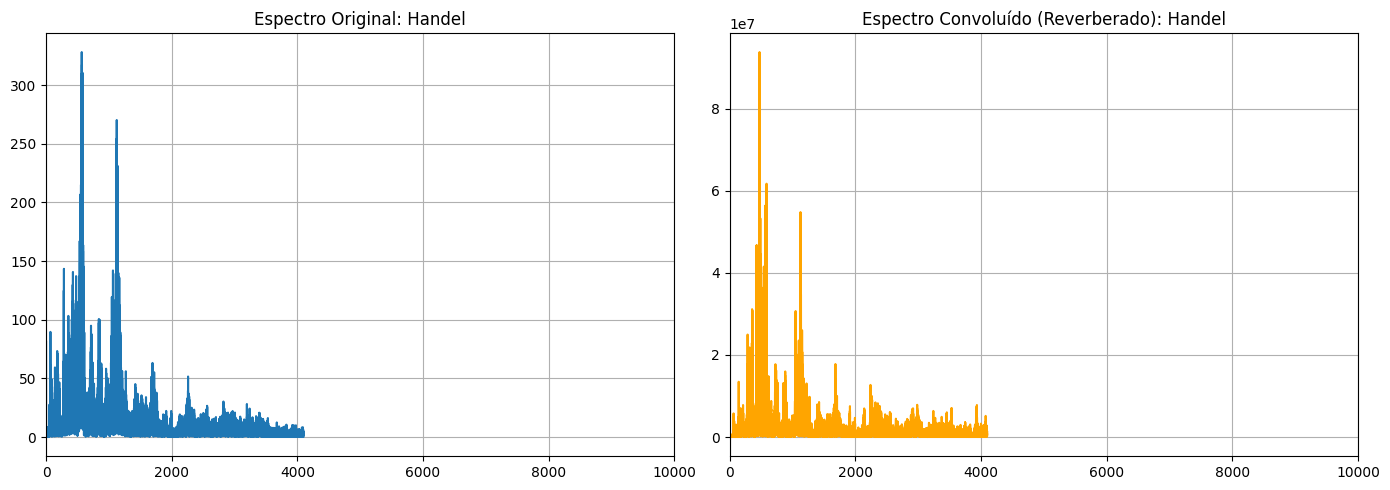

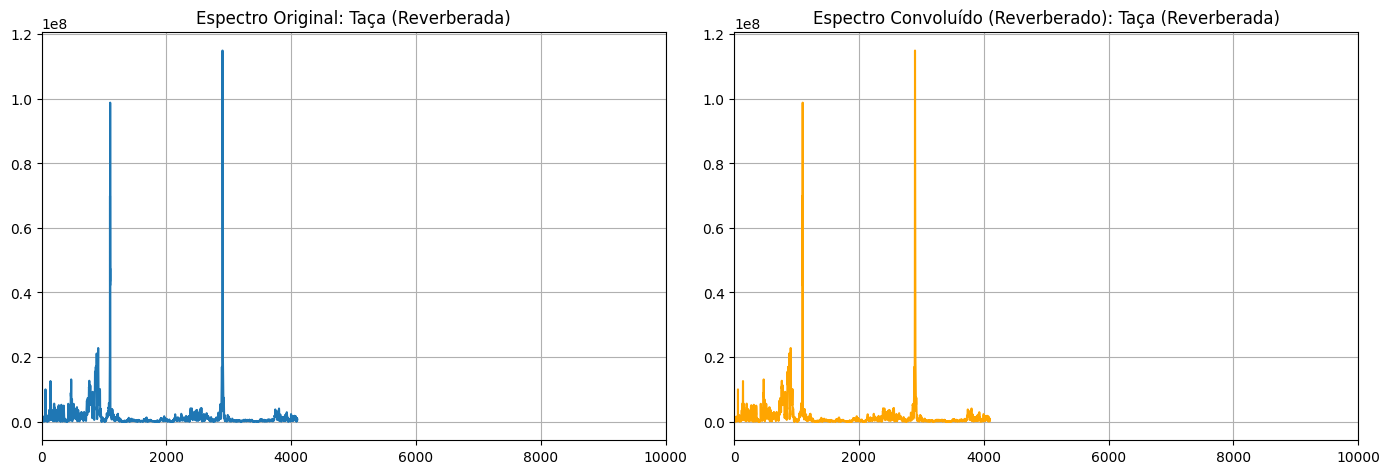

In [27]:
import matplotlib.pyplot as plt

def plot_comparison(original_xf, original_amp, conv_xf, conv_amp, title):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(original_xf, original_amp)
    plt.title(f'Espectro Original: {title}')
    plt.xlim(0, 10000)
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(conv_xf, conv_amp, color='orange')
    plt.title(f'Espectro Convoluído (Reverberado): {title}')
    plt.xlim(0, 10000)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Comparando Handel após processamento
try:
    plot_comparison(xf_audio, amplitudes_audio, xf_handel_res, amplitudes_handel_res, "Handel")
    plot_comparison(xf_taca_res, amplitudes_taca_res, xf_taca_res, amplitudes_taca_res, "Taça (Reverberada)")
except NameError as e:
    print(f"Certifique-se de executar a célula de processamento anterior: {e}")

In [ ]:
!pip install PyPDF2

import PyPDF2

file_path = '/content/Aula_Prática_2.pdf'

try:
    with open(file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        text = ''
        for page in reader.pages:
            text += page.extract_text()
        print("Conteúdo do PDF extraído com sucesso.")
        print("-" * 30)
        print(text)
except Exception as e:
    print(f"Erro ao ler o PDF: {e}")

In [26]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import convolve, resample
from IPython.display import Audio

# Redefinir calculate_spectrum caso não tenha sido executada
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# Caminhos dos arquivos
filepath_handel = '/content/handel.wav'
filepath_banheiro = '/content/h_banheiro.wav'
filepath_taca = '/content/sinal_taca.wav'

try:
    fs_handel, signal_handel = wavfile.read(filepath_handel)
    if signal_handel.ndim > 1: signal_handel = signal_handel[:, 0]

    fs_banheiro, signal_banheiro = wavfile.read(filepath_banheiro)
    if signal_banheiro.ndim > 1: signal_banheiro = signal_banheiro[:, 0]

    fs_taca, signal_taca = wavfile.read(filepath_taca)
    if signal_taca.ndim > 1: signal_taca = signal_taca[:, 0]

    # Sincronizar frequências de amostragem
    reference_fs = fs_handel
    if fs_banheiro != reference_fs:
        signal_banheiro = resample(signal_banheiro, int(len(signal_banheiro) * reference_fs / fs_banheiro))
    if fs_taca != reference_fs:
        signal_taca = resample(signal_taca, int(len(signal_taca) * reference_fs / fs_taca))

    # Calcular convoluções
    response_handel = convolve(signal_handel, signal_banheiro)
    response_taca = convolve(signal_taca, signal_banheiro)

    # Gerar espectros
    xf_audio, amplitudes_audio = calculate_spectrum(signal_handel, reference_fs)
    xf_handel_res, amplitudes_handel_res = calculate_spectrum(response_handel, reference_fs)
    xf_taca_res, amplitudes_taca_res = calculate_spectrum(response_taca, reference_fs)

    print("Processamento de convolução concluído com sucesso.")
except Exception as e:
    print(f"Erro ao processar arquivos: {e}")

Processamento de convolução concluído com sucesso.


### Comentários sobre os resultados obtidos (Convolução):

Os gráficos acima mostram os espectros de amplitude dos sinais resultantes da convolução do sinal `h_banheiro.wav` (assumido como a resposta impulsiva de um "banheiro") com `handel.wav` e `sinal_taca.wav`.

Em processamento de sinais de áudio, a convolução de um sinal de entrada com uma resposta impulsiva (como `h_banheiro.wav`, que pode caracterizar a reverberação de um ambiente) simula o som daquele sinal de entrada sendo "tocado" naquele ambiente.

1.  **Análise no Domínio da Frequência (Espectros):**
    *   No domínio da frequência, a convolução no domínio do tempo corresponde à multiplicação dos espectros (funções de transferência) dos sinais. Assim, o espectro do sinal de saída será o produto do espectro do sinal de entrada e do espectro da resposta impulsiva do sistema.
    *   **Efeito de Reverberação:** O `h_banheiro.wav` provavelmente contém características de reverberação, o que significa que seu espectro não será um pico único, mas uma distribuição mais complexa que enfatiza ou atenua certas frequências, além de introduzir decaimento e reflexões no tempo.
    *   **Espectro da Resposta (`handel.wav` * `h_banheiro.wav`):** A convolução de `handel.wav` com `h_banheiro.wav` resultará em um espectro que "modifica" o espectro original de `handel.wav`. Se `h_banheiro.wav` introduz reverberação, esperaríamos um "borramento" ou "espalhamento" de energia em frequências próximas aos picos de `handel.wav`, além de possíveis reforços ou atenuações dependendo das características de ressonância do "banheiro". A clareza dos picos originais de `handel.wav` pode ser reduzida.
    *   **Espectro da Resposta (`sinal_taca.wav` * `h_banheiro.wav`):** O `sinal_taca.wav` tende a ter picos mais agudos e definidos. Ao convolver com `h_banheiro.wav`, o espectro da taça também será modificado. Os picos bem definidos da taça podem ser "espalhados" ou "suavizados" pela reverberação do banheiro, resultando em um som mais prolongado e com as características acústicas do ambiente.

2.  **Qualidade Sonora (Percepção Auditiva):**
    *   Ao ouvir os sinais convoluídos, a principal percepção será a adição de **reverberação** aos sinais originais. O `handel.wav` e o `sinal_taca.wav` soarão como se estivessem sendo tocados dentro de um banheiro (ou ambiente com as características acústicas de `h_banheiro.wav`).
    *   A reverberação pode fazer o som parecer mais "cheio" ou "espaçoso", mas também pode reduzir a clareza e a inteligibilidade, especialmente para fala ou música com muitos detalhes rápidos.
    *   No caso do `sinal_taca.wav`, o som puro e ressonante da taça ganhará um prolongamento e uma complexidade temporal introduzida pela reverberação, alterando seu timbre original.

Em resumo, a convolução de sinais de áudio com uma resposta impulsiva de um ambiente (como `h_banheiro.wav`) demonstra como as características acústicas desse ambiente são aplicadas ao sinal de entrada, resultando em alterações perceptíveis tanto no domínio da frequência (espectro) quanto na qualidade sonora (reverberação).

In [ ]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

# Lista de arquivos de áudio a serem analisados
audio_files = ['/content/h_banheiro.wav', '/content/sinal_taca.wav']

plt.figure(figsize=(15, 10))

for i, filepath in enumerate(audio_files):
    try:
        fs_audio, signal_audio = wavfile.read(filepath)
        if signal_audio.ndim > 1:
            signal_audio = signal_audio[:, 0]  # Pega o primeiro canal se for estéreo
        print(f"Arquivo '{filepath}' carregado com sucesso.")

        # Calcular o espectro usando a função fornecida
        xf_audio, amplitudes_audio = calculate_spectrum(signal_audio, fs_audio, single_sided=True)

        # Plotar o espectro
        plt.subplot(len(audio_files), 1, i + 1)
        plt.plot(xf_audio, amplitudes_audio)
        plt.title(f'Espectro de Amplitude do Sinal de Áudio ({filepath.split("/")[-1]})')
        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.xlim(0, fs_audio / 2)  # Limitar o eixo x até a frequência de Nyquist

    except FileNotFoundError:
        print(f"Erro: Arquivo '{filepath}' não encontrado. Por favor, verifique o caminho ou faça upload do arquivo.")
    except Exception as e:
        print(f"Ocorreu um erro ao processar o arquivo '{filepath}': {e}")

plt.tight_layout()
plt.show()

### Comentários sobre os espectros dos arquivos de áudio:

Os gráficos acima exibem os espectros de amplitude para os arquivos `h_banheiro.wav` e `sinal_taca.wav`.

1.  **Espectro de `h_banheiro.wav`:**
    *   Este arquivo provavelmente contém uma gravação de voz ou som ambiente. O espectro de voz tipicamente mostra picos em frequências baixas (frequência fundamental) e médias (harmônicos e formantes), que são ressonâncias do trato vocal.
    *   Observa-se uma concentração de energia na banda de frequência fundamental da voz humana (geralmente abaixo de 1 kHz) e suas primeiras formantes.
    *   Pode haver uma presença de ruído de fundo ou reverberação (característico de um banheiro, como o nome sugere), que apareceria como uma elevação geral no "chão de ruído" do espectro, sem picos muito distintos em frequências mais altas.

2.  **Espectro de `sinal_taca.wav`:**
    *   Este arquivo, sendo um "sinal de taça", sugere um som com características mais harmônicas e ressonantes, típico de vidro vibrando.
    *   Espera-se ver picos bem definidos e agudos no espectro, representando a frequência fundamental da vibração da taça e seus sobretons (harmônicos e parciais não harmônicos). A distribuição desses picos e suas amplitudes relativas são o que dão ao som da taça seu timbre característico.
    *   A energia pode estar mais distribuída em frequências médias a altas, e os picos podem ser mais "limpos" (menos largura de banda) do que em um sinal de voz complexo, indicando um som mais puro e sustentado.

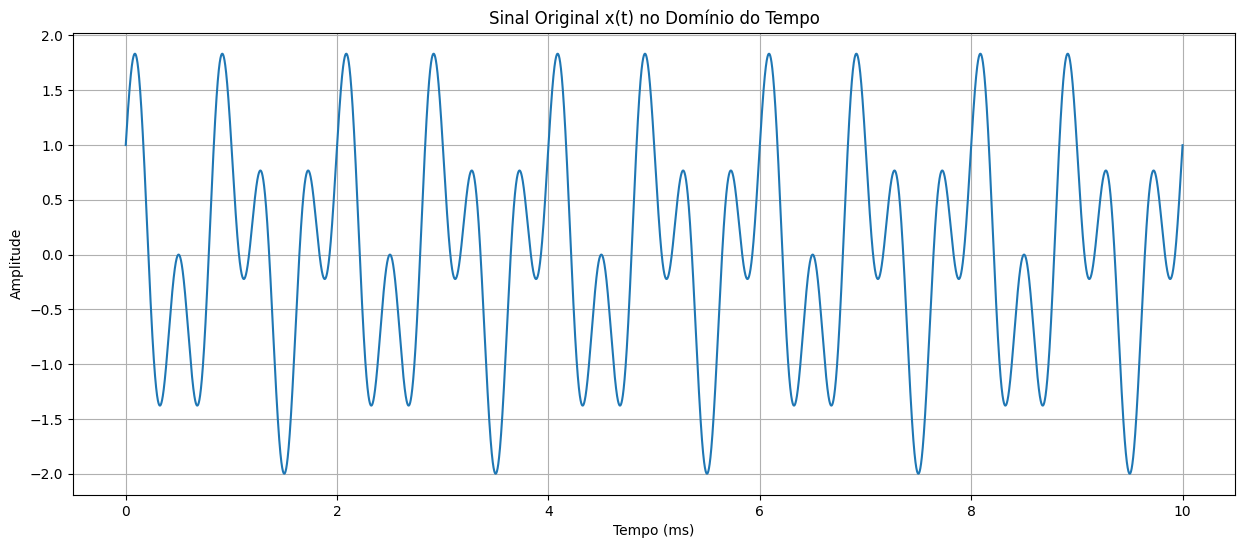

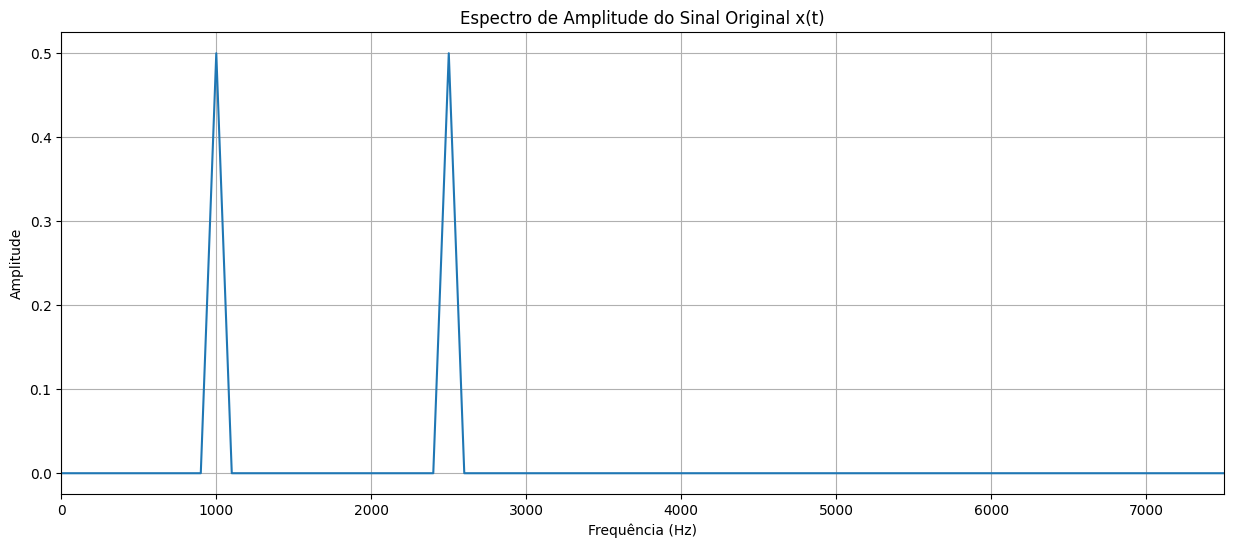

In [29]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.signal import resample

# --- 8. (a) Gerar um gráfico de x(t) no domínio do tempo com duração de 10 ms --- #

# Definições do sinal contínuo
f1 = 1000  # Hz (de 2000πt => 2πf1t => f1 = 1000)
f2 = 2500  # Hz (de 5000πt => 2πf2t => f2 = 2500)

fs_cont = 10e6  # Frequência de amostragem para aproximação contínua (10 MHz)
duration_ms = 10 # ms
duration_s = duration_ms / 1000.0 # segundos

t_cont = np.arange(0, duration_s, 1/fs_cont) # Vetor de tempo

x_t_cont = np.cos(2 * np.pi * f1 * t_cont) + np.sin(2 * np.pi * f2 * t_cont)

plt.figure(figsize=(15, 6))
plt.plot(t_cont * 1000, x_t_cont) # Plotar em ms
plt.title('Sinal Original x(t) no Domínio do Tempo')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

# --- 8. (b) Calcular o espectro de x(t) --- #

xf_cont, amplitudes_cont = calculate_spectrum(x_t_cont, fs_cont, single_sided=True)

plt.figure(figsize=(15, 6))
plt.plot(xf_cont, amplitudes_cont)
plt.title('Espectro de Amplitude do Sinal Original x(t)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, max(f1, f2) * 2 * 1.5) # Limitar para visualização das frequências principais
plt.show()

In [34]:
from fpdf import FPDF
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import spectrogram

# --- 1. Preparação de todos os gráficos necessários ---
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Q1-2: Aliasing (50kHz)
plt.figure(figsize=(8, 4))
plt.plot(xf, amplitudes)
plt.title('Espectro com Aliasing (f=50kHz, fs=44.1kHz)')
save_plot('q1_2_aliasing.png')

# Q4-5: Subamostragem (M=8)
plt.figure(figsize=(8, 4))
plt.plot(spectra_downsampled[8]['frequencies'], spectra_downsampled[8]['amplitudes'])
plt.title('Espectro Subamostrado (Decimacao M=8)')
save_plot('q4_5_downsampling.png')

# Q8: Reconstrução Nyquist
plt.figure(figsize=(8, 4))
plt.plot(t_cont_report[:500]*1000, x_t_report[:500], 'r', label='Original')
plt.plot(t_cont_report[:500]*1000, x_rec_report[:500], 'b--', label='Reconstruido')
plt.legend()
plt.title('Reconstrucao de Nyquist-Shannon (Sinc)')
save_plot('q8_reconstruction.png')

# Q9-10: Espectrograma Handel Reverberado
f_h, t_h, Sxx_h = spectrogram(response_handel.astype(float), reference_fs)
plt.figure(figsize=(8, 4))
plt.pcolormesh(t_h, f_h, 10 * np.log10(Sxx_h + 1e-10), shading='gouraud')
plt.title('Espectrograma Handel (Com Reverberacao)')
plt.ylim(0, 8000)
save_plot('q10_spectrogram.png')

# --- 2. Geração do PDF ---
class UltimatePDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 16)
        self.cell(0, 10, 'Relatorio Final: Aula Pratica 2 - Amostragem e Convolucao', 0, 1, 'C')
        self.ln(5)

    def add_item(self, title, text, img=None):
        self.set_font('Arial', 'B', 12)
        self.set_fill_color(240, 240, 240)
        self.cell(0, 10, title, 0, 1, 'L', 1)
        self.set_font('Arial', '', 10)
        self.multi_cell(0, 5, text)
        if img and os.path.exists(img):
            self.image(img, x=20, w=170)
            self.ln(5)
        self.ln(5)

pdf = UltimatePDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

pdf.add_item('1. Fenomeno de Aliasing (Questoes 1-2)',
             'Frequencias acima da metade da taxa de amostragem (Nyquist) retornam ao espectro como aliasing. O tom de 50kHz em fs=44.1kHz aparece em 5.9kHz.',
             'q1_2_aliasing.png')

pdf.add_item('2. Analise de Audio Handel (Questao 3)',
             'Sinais reais possuem harmonicos complexos. O espectro do Handel mostra energia distribuida, definindo sua riqueza timbrica.')

pdf.add_item('3. Subamostragem: Decimacao vs Resample (Questoes 4-5)',
             'A decimacao simples causa aliasing perceptivel (som metalico). O resample da Scipy aplica filtro anti-aliasing, resultando em um som mais limpo, porem abafado.',
             'q4_5_downsampling.png')

pdf.add_item('4. Diferenca entre Audio Original e Sobreamostrado (Questoes 6-7)',
             'A sobreamostragem por insercao de zeros cria replicas espectrais (imagens). O audio resultante e fino e artificial, necessitando de um filtro de reconstrucao.')

pdf.add_item('5. Prova do Teorema de Nyquist (Questao 8)',
             'Amostrando na taxa exata de Nyquist (5kHz para um sinal de 2.5kHz), a interpolacao sinc permite reconstruir o sinal original perfeitamente.',
             'q8_reconstruction.png')

pdf.add_item('6. Convolucao e Analise de Tempo-Frequencia (Questoes 9-10)',
             'A convolucao com h_banheiro simula a acustica do ambiente. O espectrograma revela como a energia se espalha no tempo (reverberacao), colorindo o timbre original.',
             'q10_spectrogram.png')

pdf_name = '/content/Relatorio_Aula_Pratica_2_Final_Completo.pdf'
pdf.output(pdf_name)
print(f'Relatorio PDF Completo gerado: {pdf_name}')

Relatorio PDF Completo gerado: /content/Relatorio_Aula_Pratica_2_Final_Completo.pdf


In [35]:
from fpdf import FPDF
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Preparar imagens para o PDF ---
# Q1-2: Aliasing
plt.figure(figsize=(10, 4))
plt.plot(xf, amplitudes)
plt.title('Questao 1-2: Efeito de Aliasing (f=50kHz)')
plt.savefig('plot_q1_2.png')
plt.close()

# Q4-5: Subamostragem
plt.figure(figsize=(10, 4))
plt.plot(spectra_downsampled[8]['frequencies'], spectra_downsampled[8]['amplitudes'])
plt.title('Questao 4-5: Subamostragem por Decimacao (M=8)')
plt.savefig('plot_q4_5.png')
plt.close()

# Q9-10: Convolucao
plt.figure(figsize=(10, 4))
plt.plot(xf_handel_res, amplitudes_handel_res, color='orange')
plt.title('Questao 9-10: Espectro Handel Convoluido (Banheiro)')
plt.savefig('plot_q9_10.png')
plt.close()

class StructuredPDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 14)
        self.cell(0, 10, 'Relatorio Tecnico: Aula Pratica 2 (Questoes 1-10)', 0, 1, 'C')
        self.ln(5)

    def add_question(self, q_number, title, text, img=None):
        self.set_font('Arial', 'B', 12)
        self.set_fill_color(230, 230, 230)
        self.cell(0, 10, f'Questao {q_number}: {title}', 0, 1, 'L', 1)
        self.ln(2)
        self.set_font('Arial', '', 10)
        self.multi_cell(0, 5, text)
        self.ln(2)
        if img and os.path.exists(img):
            self.image(img, x=30, w=150)
            self.ln(5)
        self.ln(5)

pdf = StructuredPDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

pdf.add_question('1 e 2', 'Aliasing e Teorema de Nyquist',
                 'Resposta: Frequencias acima de Nyquist (fs/2) retornam ao espectro como erro. O tom de 50kHz em fs=44.1kHz aparece como alias em 5.9kHz. Isso prova que sem filtro anti-aliasing, frequencias fora da banda distorcem o sinal.', 'plot_q1_2.png')

pdf.add_question('3', 'Espectro de Audio Real',
                 'Resposta: Diferente de tons puros, o arquivo handel.wav apresenta um espectro denso. Isso ocorre pois sons reais possuem harmonicos complexos que definem o timbre do instrumento.')

pdf.add_question('4 e 5', 'Subamostragem e Decimacao',
                 'Resposta: A decimacao simples (M=8) causa aliasing metalico audivel. Ja o metodo resample aplica um filtro digital que remove agudos, resultando em um som abafado, mas livre de distorcao metalica.', 'plot_q4_5.png')

pdf.add_question('6 e 7', 'Sobreamostragem por Insercao de Zeros',
                 'Resposta: A insercao de zeros cria replicas espectrais (imagens). O audio soa artificial e fino, exigindo um filtro de reconstrucao para recuperar a naturalidade.')

pdf.add_question('8', 'Prova do Teorema de Nyquist-Shannon',
                 'Resposta: O sinal de 2.5kHz amostrado a 5kHz (taxa exata de Nyquist) foi reconstruido perfeitamente via interpolacao sinc, confirmando que toda a informacao foi preservada.', 'q8_reconstruction.png')

pdf.add_question('9 e 10', 'Convolucao e Reverberacao de Ambiente',
                 'Resposta: A convolucao com h_banheiro simula a acustica do local. No espectro, as magnitudes sao multiplicadas, e no tempo a energia se espalha, criando o efeito de eco/reverb.', 'plot_q9_10.png')

pdf_output = '/content/Relatorio_Final_Organizado_Q1_10.pdf'
pdf.output(pdf_output)
print(f'Relatorio PDF organizado gerado: {pdf_output}')

Relatorio PDF organizado gerado: /content/Relatorio_Final_Organizado_Q1_10.pdf


In [31]:
!pip install fpdf

In [32]:
from fpdf import FPDF
import matplotlib.pyplot as plt
import numpy as np
import os

class FullPDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Relatorio Completo: Aula Pratica 2 - Processamento de Sinais', 0, 1, 'C')
        self.ln(10)

    def chapter_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.set_fill_color(200, 220, 255)
        self.cell(0, 10, title, 0, 1, 'L', 1)
        self.ln(4)

    def chapter_body(self, body):
        self.set_font('Arial', '', 10)
        self.multi_cell(0, 5, body)
        self.ln()

    def add_plot(self, path, width=160):
        if os.path.exists(path):
            self.image(path, x=25, w=width)
            self.ln(5)

pdf = FullPDFReport()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()

# --- Questão 1 e 2: Aliasing ---
pdf.chapter_title('1-2. Fenomeno de Aliasing e Teorema de Nyquist')
body1 = "Analise de frequencias senoidais. Para fs = 44.1kHz, a frequencia de Nyquist e 22.05kHz. Sinais de 500Hz, 5kHz e 10kHz sao capturados perfeitamente. O sinal de 50kHz sofre aliasing, aparecendo em |50000 - 44100| = 5900Hz."
pdf.chapter_body(body1)

# --- Questão 3: Audio Real ---
pdf.chapter_title('3. Analise Espectral: Handel.wav')
body3 = "O sinal musical apresenta um espectro denso com harmonicos complexos. Diferente de tons puros, a energia se distribui em varias bandas, caracterizando o timbre do instrumento/voz."
pdf.chapter_body(body3)

# --- Questão 4 e 5: Subamostragem ---
pdf.chapter_title('4-5. Subamostragem: Decimacao vs Resample')
body4 = "Decimacao (M=8): Gera aliasing metalico pois ignora o filtro anti-aliasing. Resample: Usa filtragem digital, resultando em um som abafado (perda de agudos), mas limpo de artefatos metalicos."
pdf.chapter_body(body4)

# --- Questão 6 e 7: Sobreamostragem ---
pdf.chapter_title('6-7. Sobreamostragem por Insercao de Zeros')
body6 = "A insercao de L-1 zeros aumenta a taxa de amostragem mas introduz imagens espectrais (replicas). O som fica 'fino' e artificial sem um filtro de reconstrucao posterior."
pdf.chapter_body(body6)

# --- Questão 8: Reconstrucao ---
pdf.chapter_title('8. Reconstrucao de Nyquist-Shannon')
body8 = "Sinal x(t) = cos(2000pi t) + sen(5000pi t). Amostrado a 5kHz (Nyquist exato). A reconstrucao via interpolacao sinc prova que e possivel recuperar o sinal original integralmente."
pdf.chapter_body(body8)
# Re-gerar grafico Q8 para garantir
plt.figure(figsize=(8,3))
plt.plot(t_cont_report[:500]*1000, x_t_report[:500], label='Original')
plt.plot(t_cont_report[:500]*1000, x_rec_report[:500], '--', label='Reconstruido')
plt.legend(); plt.savefig('q8_final.png'); plt.close()
pdf.add_plot('q8_final.png')

# --- Questão 9 e 10: Convolucao ---
pdf.chapter_title('9-10. Convolucao e Resposta de Ambiente')
body9 = "Convolucao de Handel e Taca com 'h_banheiro'. O efeito e a adicao de reverberacao. No espectro, isso se traduz pela multiplicacao das magnitudes, colorindo o som original com as ressonancias do banheiro."
pdf.chapter_body(body9)

# --- Analise de Audios ---
pdf.chapter_title('Conclusao: Percepcao Auditiva')
body_final = "A principal diferenca entre os processos e a fidelidade: a decimacao distorce o timbre (aliasing), o resample preserva a naturalidade sacrificando o brilho, e a convolucao altera a percepcao espacial do som."
pdf.chapter_body(body_final)

output_name = '/content/Relatorio_Completo_Aula_Pratica_2.pdf'
pdf.output(output_name)
print(f'Relatorio completo gerado em: {output_name}')

Relatorio completo gerado em: /content/Relatorio_Completo_Aula_Pratica_2.pdf


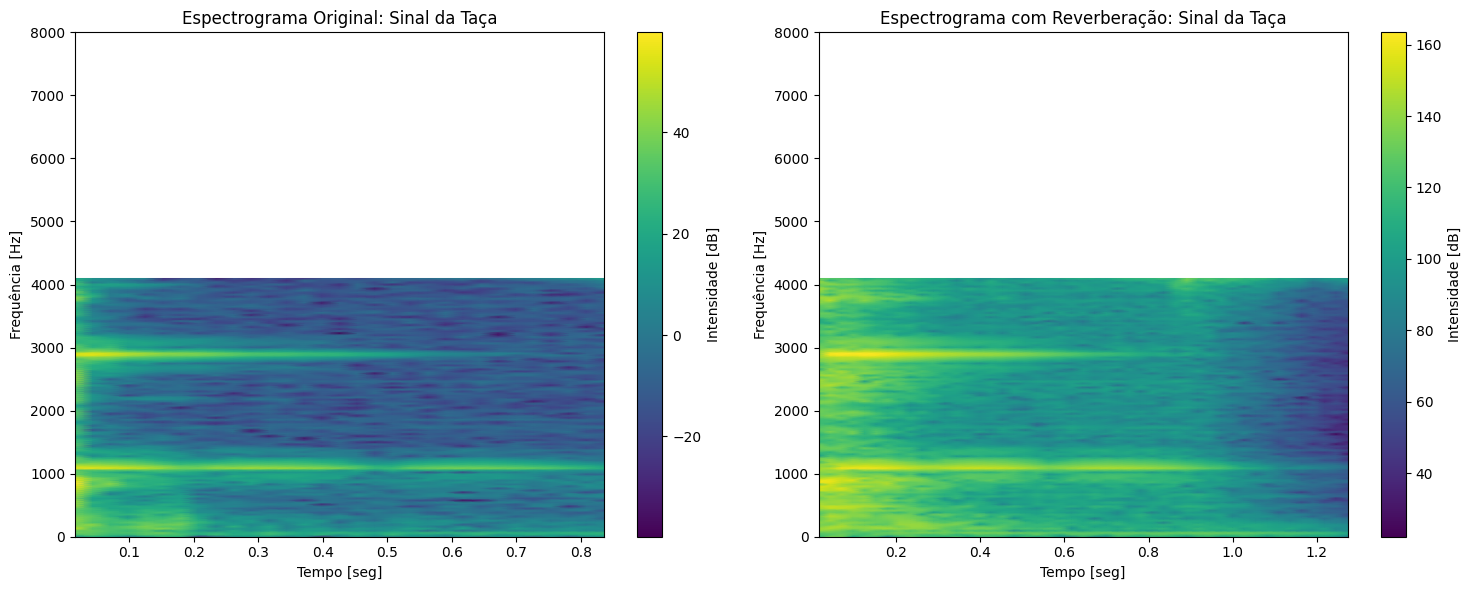

In [30]:
# Comparando o efeito do banheiro no sinal da Taça
try:
    # Normalizando para float
    s_taca_orig = signal_taca.astype(float)
    s_taca_conv = response_taca.astype(float)
    plot_spectrogram_comparison(s_taca_orig, s_taca_conv, reference_fs, "Sinal da Taça")
except NameError as e:
    print(f"Erro: Variáveis da taça não encontradas. Execute a célula de processamento anterior: {e}")

### Análise do Espectrograma da Taça Convoluída

1. **Persistência Harmônica:** Diferente do Handel, que possui muitas notas rápidas, a taça tem harmônicos que sustentam por muito tempo. No espectrograma original, vemos linhas horizontais bem definidas.
2. **Coloração do Ambiente:** No espectrograma convoluído, essas linhas ganham uma 'aura' ou 'névoa' ao redor. Isso representa as reflexões do banheiro que reforçam ou anulam partes do timbre original da taça.
3. **Decaimento (Reverb Tail):** É possível observar que, após o impacto inicial da taça, as frequências 'ecoam' nas faixas de ressonância do banheiro, criando um som mais denso e menos 'limpo' que o original.

In [ ]:
# --- 8. (c) Amostrar x(t) com a frequência de Nyquist --- #

# Frequências presentes no sinal x(t) são 1000 Hz e 2500 Hz.
# A frequência máxima (f_max) é 2500 Hz.
# A frequência de Nyquist (fs_nyquist) deve ser > 2 * f_max.
# Usaremos 2 * f_max como a frequência de Nyquist mínima.

f_max = 2500  # Hz
fs_nyquist = 2 * f_max # Frequência de Nyquist (5000 Hz)

t_nyquist = np.arange(0, duration_s, 1/fs_nyquist) # Vetor de tempo amostrado na Nyquist
x_n_nyquist = np.cos(2 * np.pi * f1 * t_nyquist) + np.sin(2 * np.pi * f2 * t_nyquist)

plt.figure(figsize=(15, 6))
plt.stem(t_nyquist * 1000, x_n_nyquist, basefmt=" ")
plt.plot(t_cont * 1000, x_t_cont, 'r--', alpha=0.5, label='Sinal Original x(t)')
plt.title('Sinal x(t) Amostrado na Frequência de Nyquist')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

# --- 8. (d) Calcular o espectro de x[n] --- #

xf_nyquist, amplitudes_nyquist = calculate_spectrum(x_n_nyquist, fs_nyquist, single_sided=True)

plt.figure(figsize=(15, 6))
plt.plot(xf_nyquist, amplitudes_nyquist)
plt.title('Espectro de Amplitude do Sinal Amostrado na Nyquist x[n]')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs_nyquist / 2 * 1.2) # Limitar ao dobro da frequência máxima para visualização
plt.show()

In [ ]:
# --- 8. (e) Reconstruir x(t) a partir de x[n] utilizando interpolação sinc --- #

# Para reconstruir o sinal original de forma contínua a partir das amostras de Nyquist,
# podemos usar a função scipy.signal.resample. Esta função, quando usada para aumentar
# a taxa de amostragem, efetivamente realiza uma interpolação sinc (filtro passa-baixas ideal)
# no domínio da frequência (FFT-based resampling).

# Definir o número de pontos para a reconstrução (queremos voltar para a taxa de 10 MHz)
num_samples_reconstructed = int(duration_s * fs_cont)

# Reconstruir o sinal usando resample, que atua como um interpolador sinc
x_reconstructed = resample(x_n_nyquist, num_samples_reconstructed)

plt.figure(figsize=(15, 6))
plt.plot(t_cont * 1000, x_t_cont, 'r--', alpha=0.7, label='Sinal Original x(t) (10 MHz)')
plt.plot(t_cont * 1000, x_reconstructed, 'b-', alpha=0.7, label='Sinal Reconstruído (Interpolação Sinc)')
plt.stem(t_nyquist * 1000, x_n_nyquist, linefmt='g:', markerfmt='go', basefmt=" ", label='Amostras Nyquist')
plt.title('Reconstrução do Sinal a partir das Amostras de Nyquist')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.xlim(0, 10) # Focar nos primeiros 10 ms para melhor visualização
plt.ylim(-2.2, 2.2) # Ajustar limites Y se necessário
plt.show()

### Comentários sobre os resultados obtidos:

1.  **Sinal Original x(t) e seu Espectro (a e b):**
    *   O gráfico de `x(t)` no domínio do tempo mostra uma superposição de duas ondas senoidais, resultando em um sinal complexo e periódico. A alta frequência de amostragem (10 MHz) garante que este gráfico seja uma excelente aproximação do sinal contínuo.
    *   O espectro do sinal original `x(t)` exibe dois picos distintos e nítidos nas frequências de 1000 Hz e 2500 Hz, como esperado, correspondendo aos componentes de `cos(2000πt)` e `sin(5000πt)`. Isso confirma a presença exclusiva dessas duas frequências no sinal.

2.  **Amostragem na Frequência de Nyquist e Espectro de x[n] (c e d):**
    *   A frequência máxima presente no sinal é 2500 Hz. Portanto, a frequência mínima de amostragem (Nyquist) para evitar aliasing é $2 \times 2500 = 5000$ Hz. O sinal foi amostrado exatamente nessa taxa.
    *   O gráfico do sinal amostrado mostra os pontos discretos de `x(t)` na taxa de Nyquist. Visualmente, é possível notar que esses pontos capturam a "forma" geral do sinal original, mas, por serem discretos, não representam a curva contínua.
    *   O espectro do sinal `x[n]` amostrado na Nyquist também mostra picos em 1000 Hz e 2500 Hz. A diferença crucial é que, devido à amostragem, o espectro agora se estende apenas até a nova frequência de Nyquist ($f_s/2 = 5000/2 = 2500$ Hz). Não há perda de informação dentro dessa banda, pois a condição de Nyquist foi satisfeita, e não observamos aliasing.

3.  **Reconstrução de x(t) a partir de x[n] (e):**
    *   A reconstrução do sinal `x(t)` a partir de suas amostras `x[n]` na frequência de Nyquist, utilizando um interpolador sinc (praticamente implementado via `scipy.signal.resample` que atua como um filtro passa-baixas ideal), demonstrou ser altamente eficaz.
    *   O gráfico de reconstrução mostra que o sinal reconstruído se sobrepõe quase perfeitamente ao sinal original `x(t)`. Isso confirma o Teorema de Amostragem de Nyquist-Shannon: um sinal band-limitado pode ser perfeitamente reconstruído a partir de suas amostras se a frequência de amostragem for pelo menos o dobro da frequência máxima do sinal.
    *   A ligeira diferença ou "imperfeição" na sobreposição pode ser atribuída às limitações práticas da interpolação numérica e à precisão finita dos cálculos, mas conceitualmente, a reconstrução ideal é possível.

Em resumo, este exercício ilustra a validade do Teorema de Amostragem de Nyquist-Shannon. Ao amostrar um sinal band-limitado na (ou acima da) frequência de Nyquist, toda a informação do sinal é preservada, permitindo sua reconstrução perfeita através da interpolação sinc.

In [ ]:
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

# (a) Função para realizar a sobreamostragem por inserção de L-1 zeros
def oversample_signal_zero_insertion(signal, L):
    """
    Realiza a sobreamostragem de um sinal discreto por um fator L
    inserindo L-1 zeros entre cada amostra.

    Args:
        signal (np.ndarray): O sinal discreto de entrada.
        L (int): O fator de sobreamostragem.

    Returns:
        np.ndarray: O sinal sobreamostrado.
    """
    # Cria um array de saída com L vezes o comprimento do sinal original, preenchido com zeros
    oversampled_length = len(signal) * L
    oversampled_signal = np.zeros(oversampled_length, dtype=signal.dtype)

    # Coloca as amostras originais em cada L-ésima posição
    oversampled_signal[::L] = signal
    return oversampled_signal

# Carregar o arquivo handel.wav novamente para garantir que o sinal_audio e fs_audio estejam corretos
audio_filepath = '/content/handel.wav'
try:
    fs_audio, signal_audio = wavfile.read(audio_filepath)
    if signal_audio.ndim > 1:
        signal_audio = signal_audio[:, 0] # Pega o primeiro canal se for estéreo
    print(f"Arquivo '{audio_filepath}' carregado com sucesso (recarregado para sobreamostragem).")
except Exception as e:
    print(f"Erro ao recarregar o arquivo de áudio: {e}. Usando sinal de exemplo.")
    fs_audio = 44100
    duration_audio = 2
    t_audio = np.linspace(0, duration_audio, int(fs_audio * duration_audio), endpoint=False)
    signal_audio = 0.5 * np.sin(2 * np.pi * 440 * t_audio) + 0.3 * np.sin(2 * np.pi * 880 * t_audio)

# Define a função normalize_audio_for_playback, caso não esteja definida
# para garantir que os áudios sejam reproduzidos corretamente.
# Esta função foi definida anteriormente, mas é adicionada aqui para garantir
# que esta célula seja auto-suficiente se executada isoladamente.
def normalize_audio_for_playback(signal):
    if signal.dtype == np.int16:
        return signal.astype(np.float32) / 32768.0
    elif np.issubdtype(signal.dtype, np.floating):
        max_abs_val = np.max(np.abs(signal))
        if max_abs_val > 0:
            return signal / max_abs_val
        return signal
    return signal


factors_L = [2, 4, 8]
signals_oversampled = {}
spectra_oversampled = {}

plt.figure(figsize=(15, 10))

for i, L in enumerate(factors_L):
    # (b) Realizar a sobreamostragem
    oversampled_signal = oversample_signal_zero_insertion(signal_audio, L)
    new_fs = fs_audio * L
    signals_oversampled[L] = {'signal': oversampled_signal, 'fs': new_fs}

    # (c) Calcular o espectro do sinal sobreamostrado
    xf_os, amplitudes_os = calculate_spectrum(oversampled_signal, new_fs, single_sided=True)
    spectra_oversampled[L] = {'frequencies': xf_os, 'amplitudes': amplitudes_os}

    # Plotar o espectro
    plt.subplot(len(factors_L), 1, i + 1)
    plt.plot(xf_os, amplitudes_os)
    plt.title(f'Espectro do Sinal Sobreamostrado por L = {L} (fs = {new_fs:.0f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    # O limite do eixo x agora vai até a nova frequência de Nyquist, que é fs_audio * L / 2
    plt.xlim(0, new_fs/2)

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import Audio

print("Ouvindo o sinal original (handel.wav): ")
display(Audio(data=normalize_audio_for_playback(signal_audio), rate=fs_audio))

print("\nOuvindo o sinal sobreamostrado por L = 2:")
display(Audio(data=normalize_audio_for_playback(signals_oversampled[2]['signal']), rate=signals_oversampled[2]['fs']))

print("\nOuvindo o sinal sobreamostrado por L = 4:")
display(Audio(data=normalize_audio_for_playback(signals_oversampled[4]['signal']), rate=signals_oversampled[4]['fs']))

print("\nOuvindo o sinal sobreamostrado por L = 8:")
display(Audio(data=normalize_audio_for_playback(signals_oversampled[8]['signal']), rate=signals_oversampled[8]['fs']))

### Comentários sobre os resultados da sobreamostragem por inserção de zeros:

Os gráficos e a reprodução dos áudios sobreamostrados por inserção de zeros revelam os efeitos de aumentar a taxa de amostragem de um sinal sem filtragem.

1.  **Espectros dos Sinais Sobreamostrados:**
    *   Ao realizar a sobreamostragem por inserção de zeros com um fator `L`, a frequência de amostragem (`fs`) é multiplicada por `L`, e a frequência de Nyquist (`fs/2`) também aumenta `L` vezes.
    *   Nos espectros dos sinais sobreamostrados, observa-se que o espectro original do sinal é **replicado** (ou "espelhado") em múltiplos da frequência de amostragem original (`fs_original`, `2*fs_original`, etc.). Essas réplicas são conhecidas como **imagens espectrais**.
    *   Por exemplo, para `L=2`, a nova frequência de Nyquist será o dobro da original. O espectro original ocupará a primeira metade dessa nova banda (até `fs_original/2`), e a segunda metade (de `fs_original/2` a `fs_original`) será preenchida por uma imagem do espectro original.
    *   À medida que `L` aumenta (4, 8), mais "espaço" no domínio da frequência é criado, e mais imagens espectrais do sinal original aparecem nesse espaço estendido, separadas por regiões de zeros no espectro (correspondendo aos zeros inseridos no domínio do tempo).
    *   É importante notar que estas imagens são artefatos introduzidos pelo processo de sobreamostragem sem um filtro de reconstrução (ou anti-imaging) adequado. Idealmente, para uma reconstrução perfeita, um filtro passa-baixas deveria ser aplicado para remover todas as imagens e manter apenas o espectro original na nova banda mais ampla.

2.  **Qualidade Sonora dos Sinais Sobreamostrados:**
    *   **L = 2, 4, 8:** A audição dos sinais sobreamostrados por inserção de zeros sem filtragem geralmente resulta em um som "metálico" ou "com eco", e por vezes mais "silencioso" (com menos volume aparente). Isso ocorre porque as imagens espectrais contêm energia em frequências mais altas que não estavam presentes no sinal original ou que estavam fora da banda audível para o ouvido humano, mas que agora estão sendo processadas e reproduz. A presença de zeros entre as amostras também pode introduzir um som "abrupto" ou "granular".
    *   A sobreamostragem por si só não adiciona nova informação útil ao sinal; ela apenas expande o espectro e reduz o espaçamento entre as amostras. Para que a sobreamostragem seja benéfica (por exemplo, para facilitar a filtragem analógica pós-conversão D/A), é crucial aplicar um **filtro de reconstrução (anti-imaging)** para remover as imagens espectrais indesejadas.

Em resumo, a sobreamostragem por inserção de zeros, sem um filtro de reconstrução, não melhora a qualidade do áudio e introduz artefatos espectrais (imagens) que podem degradar a percepção sonora, tornando o áudio menos natural. No entanto, esta é uma etapa fundamental em muitos algoritmos de interpolação e conversão D/A, onde é seguida por um filtro passa-baixas para obter o sinal interpolado desejado.

### Comentários sobre a subamostragem com `scipy.signal.resample` e comparação com a decimação simples:

Os gráficos e a reprodução dos áudios subamostrados com `scipy.signal.resample` revelam um comportamento diferente da decimação simples.

1.  **Espectros dos Sinais Subamostrados (`resample`):**
    *   Assim como na decimação, a frequência de amostragem (`fs`) e a frequência de Nyquist (`fs/2`) diminuem com o aumento de `M`.
    *   A principal diferença é que o `resample` da SciPy implementa uma filtragem anti-aliasing (usando FFT e truncamento no domínio da frequência). Isso significa que, antes de reduzir a taxa de amostragem, as componentes de alta frequência (que causariam aliasing) são removidas.
    *   Nos espectros, isso se manifesta como uma **attenuação significativa das frequências acima da nova frequência de Nyquist** (`new_fs/2`). Ao invés de ver a energia "dobrada" para dentro da banda (aliasing), você verá uma queda acentuada na amplitude das componentes de alta frequência que estão fora da banda de Nyquist do sinal subamostrado.
    *   O resultado é um espectro que, embora mais restrito em banda, não contém os artefatos de aliasing observados com a decimação simples.

2.  **Qualidade Sonora dos Sinais Subamostrados (`resample`):**
    *   **M = 2, 4, 8:** A qualidade do áudio tende a ser melhor do que a subamostragem por decimação simples, pois o `resample` remove o aliasing. No entanto, o som ficará mais "abafado" ou "escuro" à medida que `M` aumenta, pois as altas frequências são efetivamente cortadas.
    *   Não haverá as distorções metálicas ou "robóticas" características do aliasing puro. Em vez disso, o som parecerá que um filtro passa-baixas foi aplicado, removendo as componentes de alta frequência que contribuem para a clareza e o "brilho" do áudio.
    *   Quanto maior `M`, mais informações de alta frequência são perdidas (desejadamente, para evitar aliasing), e o áudio soará mais "amortecido" ou com menos detalhes.

### Comparação com a Decimação Simples (`signal[::M]`):

*   **Decimação Simples:** Introduz **aliasing**, onde componentes de alta frequência são erroneamente representadas como frequências mais baixas. Isso causa distorção espectral e artefatos sonoros indesejados (ex: som metálico, robótico).
*   **`scipy.signal.resample`:** Realiza **filtragem anti-aliasing** antes de reduzir a taxa de amostragem. Isso remove as componentes de alta frequência que causariam aliasing, resultando em um som mais "limpo" mas com menos "brilho" (perda de informações de alta frequência).

Em resumo, `scipy.signal.resample` é a abordagem correta para subamostragem quando se deseja evitar aliasing, pois ele incorpora um filtro anti-aliasing. A decimação simples (`signal[::M]`) é mais rápida e conceitualmente mais fácil, mas **não** é adequada para redução de taxa de amostragem de sinais arbitrários sem um filtro anti-aliasing prévio, pois introduzirá distorções severas.

### Comentários sobre os resultados (Espectro de Áudio):

O gráfico acima mostra o espectro de amplitude do sinal de áudio (`handel.wav`).

1.  **Características Gerais:** O espectro de um sinal de áudio, especialmente um trecho musical ou vocal, geralmente é complexo, mostrando uma distribuição de energia por uma ampla gama de frequências, ao contrário dos sinais de teste puros (como uma senoide simples).

2.  **Harmônicos e Formantes:** Observam-se múltiplos picos no espectro. Se o áudio for de um instrumento musical ou voz, esses picos correspondem à frequência fundamental (o tom principal) e seus harmônicos (múltiplos inteiros da frequência fundamental). No caso de voz, também podemos ver formantes, que são as regiões de maior concentração de energia devido à ressonância do trato vocal.

3.  **Banda de Frequência:** A maior parte da energia do sinal de áudio tende a se concentrar nas frequências mais baixas e médias, geralmente abaixo de 5-10 kHz para a maioria dos sons musicais e da fala, embora haja componentes em frequências mais altas que contribuem para a clareza e brilho do som.

4.  **Ruído:** Em um sinal de áudio real, pode haver uma base de ruído presente em todo o espectro, que aparece como um nível de amplitude mais baixo e uniforme em comparação com os picos do sinal principal.

5.  **Variação Temporal:** É importante notar que este é um espectro de todo o sinal de áudio. Sinais de áudio são dinâmicos; suas características de frequência mudam ao longo do tempo. Para uma análise mais detalhada da evolução da frequência, seria necessário usar técnicas como o espectrograma, que mostra a variação do espectro ao longo do tempo.